# Daegu Apartment Price Prediction — Regression Pipeline
#### Prepared by: Kemal Aditya Permana - JCAIEAH004

[Daegu Apartment Data](https://drive.google.com/file/d/1MPDotXZNmiq6geRi8BkGd-fjttzoyTxW/view?usp=share_link)

**Table of Content:**
1. Business Problem  
2. Data Load & Inspect
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Feature Engineering & Selection
6. Modeling
7. Model Evaluation
8. Conclusion & Recommendation

------


## 0. Library Import
----

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBRegressor

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Business Problem
----



**Problem Context**

Apartemen merupakan salah satu solusi untuk kebutuhan tempat tinggal akan terbatasnya lahan. Adanya kebutuhan untuk memahami bagaimana harga apartemen ditentukan berdasarkan berbagai faktor dari apartemen itu sendiri ataupun faktor eksternal seperti fasilitas sekitar namun masih banyak pemilik apartemen menentukan harga berdasarkan *feeling* bukan berdasarkan data-data yang ada. Contoh kasus pada dokumen ini akan membahas apartemen di daerah *Daegu* - salah satu kota di Korea Selatan.

**Problem utama** yang akan diselesaikan adalah membantu pemilik/agen apartemen untuk menentukan harga OPTIMAL berdasarkan data-data yang ada dan memastikan kesesuaian dengan harga pasar untuk mencegah kemungkinan
  * **Overpricing**: Harga yang terlalu mahal akan menyebabkan apartemen tidak mudah laku namun biaya-biaya yang lain masih perlu ditanggung oleh pemilik tanpa ada arus kas untuk menutupi biaya tersebut
  * **Underpricing**: Harga yang terlalu murah menyebabkan apartemen tersebut dapat laku dengan cepat namun pendapatan dari penjualan apartemen tidak optimal bagi pemilik

**Tujuan** kasus ini akan membahas bagaimana membuat model Machine Learning yang dapat digunakan sebagai *tool* bagi pemilik/agen apartemen dalam *menentukan harga jual* apartemen ('SalePrice') berdasarkan berbagai faktor baik data internal ataupun eksternal. Pemilik/agen dapat memiliki nilai panduan jual harga apartemen (dengan batas atas dan bawah berdasarkan seberapa besar batas error yang didapat melalui model). Selain itu, melalui model ini kita juga dapat mengetahui faktor apa yang paling berpengaruh dalam menentukan harga apartemen.

**Data Understanding**

Pada bagian ini akan memahami fitur yang kita miliki di dalam data untuk diproses lebih lanjut. Jika dilihat sekilas terdapat 2 kategori utama dalam penentuan harga jual apartemen:
  * Faktor Internal:
    * Tipe Hallway (`HallwayType`)
    * Lahan Parkir (`N_Parkinglot(Basement)`)
    * Tahun Pembangunan (`YearBuilt`)
    * Fasilitas dalam Apartment (`N_FacilitiesInApt`)
    * Luas Apartemen (`Size(sqf)`)
  * Faktor Eksternal:
    * Stasiun Terdekat (`TimeToSubway`)
    * Waktu menuju Stasiun (`SubwayStation`)
    * Fasilitas Sekitar (`N_FacilitiesNearBy(ETC)`)
    * Area Perkantoran (`N_FacilitiesNearBy(PublicOffice)`)
    * Area persekolahan (`N_SchoolNearBy(University)`)

| Feature | Representasi |
|---|---|
| `HallwayType` | Akses apartemen (`corridor`, `terraced`, `mixed`) — dapat mempengaruhi kualitas/kelas apartemen |
| `TimeToSubway` | Waktu yang dibutuhkan untuk menuju stasiun Subway terdekat |
| `SubwayStation` | Nama stasiun Subway terdekat - sebagai acuan terhadap area/lokasi yang menarik atau tidak |
| `N_FacilitiesNearBy(ETC)` | Jumlah fasilitas lain yang tedekat |
| `N_FacilitiesNearBy(PublicOffice)` | Jumlah fasilitas kantor publik |
| `N_SchoolNearBy(University)` | Jumlah universitas terdekat (opportunity untuk area sewa oleh mahasiswa) |
| `N_Parkinglot(Basement)` | Jumlah parkir basement - untuk kota yang padat penduduk menjadi hal yang cukup langka |
| `YearBuilt` | Tahun pembangunan Apartemen — sebagai acuan untuk kualitas gedung atau bangunan baru/tidak |
| `N_FacilitiesInApt` | Fasilitas didalam area apartemen (gym, playground, dll) |
| `Size(sqf)` | Luas area dari Apartemen |
| `SalePrice` | **Target** — Harga Jual yang ditawarkan dalam Won |

**Analytics Process Flow**

Dokumen ini akan memulai proses analisis dengan beberapa step
1. Data Load & Inspect: Memanggil data dan melakukan inspeksi pengecekan dasar
2. Exploratory Data Analysis: Melakukan analisis dasar untuk mendapatkan insight-insight tambahan
3. Data Preprocessing: Mengolah data sebelum digunakan untuk digunakan dalam training Model Machine Learning
4. Feature Engineering & Selection: Melakukan penambahan/pengurangan feature yang akan digunakan dalam training Model Machine Learning
5. Modeling: Membuat arsitektur Model Learning
6. Model Evaluation: Melakukan evaluasi terhadap Model yang sudah dibuat dan menilai apakah model dapat menjawab masalah utama yang telah dipaparkan atau tidak
7. Conclusion & Recommendation: Merangkum seluruh proses dan memberikan rekomendasi untuk perbaikan model yang lebih baik kedepannya

**Modeling Approach**

Pada model Machine Learning kali ini akan dipilih menggunakan pendekatan model **Regresi** dikarenakan target variabel kita adalah `SalePrice` yang merupakan *continuous number*. Dengan menggunakan Regresi, model dapat mengetahui dari berbagai faktor yang ada untuk menghasilkan harga prediksi sebagai acuan utama dari stakeholders untuk menentukan harga jual apartemen.

**Evaluation Approach**

Dalam melakukan analisis Model Regresi maka metode evaluasi yang tepat akan menggunakan beberapa metrik seperti MAE (Mean Absolute Error), RMSE (Root of Mean Squared Error), MAPE (Mean Absolute Percentage Error) dan R² untuk melihat apakah model tersebut dapat digunakan dengan tingkat kepercayaan yang tinggi:

| Metrik | Penjelasan | Interpretasi |
|---|---|---|
| MAE | Rata-rata selisih absolut antara prediksi dan nilai asli. | Semakin kecil, semakin baik. |
| RMSE | Akar rata-rata kuadrat kesalahan; lebih sensitif terhadap kesalahan besar. | Semakin kecil, semakin baik. |
| MAPE | Rata-rata persentase selisih antara prediksi dan nilai asli. | Semakin kecil, semakin baik; hindari jika nilai asli 0 atau mendekati 0. |
| R² | Proporsi variasi nilai target yang dapat dijelaskan oleh model. | Semakin dekat ke 1, semakin baik. |

Sebagai goal awal - kita akan menggunakan goal MAPE ≤20%, dimana model yang berguna akan mampu memprediksi harga dengan margin error dibawah 20% sebagai bahan evaluasi di bagian akhir.

## 2. Data Load & Inspect
----



Pada bagian ini - data akan di-*load* dan ditampilkan pengecekan dasar berupa
1. Jumlah baris dan kolom yang tersedia
2. Jenis tipe data pada masing-masing kolom
3. Pengecekan Data Missing & Data Duplikat
4. Pengecekan Statistik Dasar untuk Data Numerik & Kategori
5. Pengecekan distribusi data pada Data Kategori

In [2]:
# Melakukan Load Data pada notebook dan melakukan pengecekan awal pada 5 data pertama

df = pd.read_csv("data_daegu_apartment.csv")

print(f"Jumlah Data: {df.shape[0]} baris, {df.shape[1]} kolom")
print("Menampilkan 5 data pertama: ")
df.head()

Jumlah Data: 4123 baris, 11 kolom
Menampilkan 5 data pertama: 


,HallwayType,TimeToSubway,SubwayStation,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,N_FacilitiesInApt,Size(sqf),SalePrice
0,terraced,0-5min,Kyungbuk_uni_hospital,0.0,3.0,2.0,1270.0,2007,10,1387,346017
1,terraced,10min~15min,Kyungbuk_uni_hospital,1.0,5.0,1.0,0.0,1986,4,914,150442
2,mixed,15min~20min,Chil-sung-market,1.0,7.0,3.0,56.0,1997,5,558,61946
3,mixed,5min~10min,Bangoge,5.0,5.0,4.0,798.0,2005,7,914,165486
4,terraced,0-5min,Sin-nam,0.0,1.0,2.0,536.0,2006,5,1743,311504


In [3]:
# Melakukan pengecekan kolom dan tipe data pada masing-masing kolom

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4123 entries, 0 to 4122
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   HallwayType                       4123 non-null   object 
 1   TimeToSubway                      4123 non-null   object 
 2   SubwayStation                     4123 non-null   object 
 3   N_FacilitiesNearBy(ETC)           4123 non-null   float64
 4   N_FacilitiesNearBy(PublicOffice)  4123 non-null   float64
 5   N_SchoolNearBy(University)        4123 non-null   float64
 6   N_Parkinglot(Basement)            4123 non-null   float64
 7   YearBuilt                         4123 non-null   int64  
 8   N_FacilitiesInApt                 4123 non-null   int64  
 9   Size(sqf)                         4123 non-null   int64  
 10  SalePrice                         4123 non-null   int64  
dtypes: float64(4), int64(4), object(3)
memory usage: 354.4+ KB


In [4]:
# Melakukan pengecekan data yang kosong atau data duplikat

print("Menampilkan Missing Value per Kolom:")
print(df.isna().sum())

duplikat = df.duplicated().sum()

print(f"\nJumlah Baris yang duplikat: {duplikat:,} ({duplikat/len(df)*100:.1f}%)")

Menampilkan Missing Value per Kolom:
HallwayType                         0
TimeToSubway                        0
SubwayStation                       0
N_FacilitiesNearBy(ETC)             0
N_FacilitiesNearBy(PublicOffice)    0
N_SchoolNearBy(University)          0
N_Parkinglot(Basement)              0
YearBuilt                           0
N_FacilitiesInApt                   0
Size(sqf)                           0
SalePrice                           0
dtype: int64

Jumlah Baris yang duplikat: 1,422 (34.5%)


In [5]:
# Melakukan pengecekan statistik dasar untuk Data Numerik & Kategori

print("Menampilkan Statistik Dasar untuk Data Numerik: ")
display(df.describe().T)

print("\nMenampilkan Statistik Dasar untuk Data Kategori: ")
display(df.describe(include="object").T)

Menampilkan Statistik Dasar untuk Data Numerik: 


,count,mean,std,min,25%,50%,75%,max
N_FacilitiesNearBy(ETC),4123.0,1.930876,2.198832,0.0,0.0,1.0,5.0,5.0
N_FacilitiesNearBy(PublicOffice),4123.0,4.135338,1.802640,0.0,3.0,5.0,5.0,7.0
N_SchoolNearBy(University),4123.0,2.746301,1.496610,0.0,2.0,2.0,4.0,5.0
N_Parkinglot(Basement),4123.0,568.979141,410.372742,0.0,184.0,536.0,798.0,1321.0
YearBuilt,4123.0,2002.999757,8.905768,1978.0,1993.0,2006.0,2008.0,2015.0
N_FacilitiesInApt,4123.0,5.817851,2.340507,1.0,4.0,5.0,7.0,10.0
Size(sqf),4123.0,954.630851,383.805648,135.0,644.0,910.0,1149.0,2337.0
SalePrice,4123.0,221767.926995,106739.839945,32743.0,144752.0,209734.0,291150.0,585840.0



Menampilkan Statistik Dasar untuk Data Kategori: 


,count,unique,top,freq
HallwayType,4123,3,terraced,2528
TimeToSubway,4123,5,0-5min,1953
SubwayStation,4123,8,Kyungbuk_uni_hospital,1152


In [6]:
# Melakukan pengecekan jumlah data pada data kategori

for col in ["HallwayType", "TimeToSubway", "SubwayStation"]:
    print(f"--- {col} ---")
    display(df[col].value_counts())
    print()

--- HallwayType ---


,count
HallwayType,
terraced,2528
mixed,1131
corridor,464



--- TimeToSubway ---


,count
TimeToSubway,
0-5min,1953
5min~10min,787
15min~20min,629
10min~15min,583
no_bus_stop_nearby,171



--- SubwayStation ---


,count
SubwayStation,
Kyungbuk_uni_hospital,1152
Myung-duk,1044
Banwoldang,529
Bangoge,502
Sin-nam,467
no_subway_nearby,290
Chil-sung-market,74
Daegu,65


### Initial Insights:

* Dataset Daegu Apartment memiliki 11 Feature terdiri dari **3 Feature Kategori** dan **8 Feature Numerik** - dengan total jumlah data sebanyak **4,123 data**
* Berdasarkan hasil pengecekan, tidak terdapat Missing Value pada dataset namun terdapat sekitar **1,422** data point yang duplikat sama persis atau sekitar **34.5%** dari dataset
* Melalui proses **Data Load & Inspect**, terdapat beberapa hal sebagai insight awal
  * Melalui pengecekan data numerikal:
    * Secara rata-rata, tiap apartemen memiliki ~2 fasilitas umum disekitarnya dengan ~3 universitas dan ~4 kantor publik
    * Rata-rata apartemen di Daegu merupakan apartemen yang dibangun pada 2002 namun juga terdapat apartemen tertua yang dibangun pada 1978 ataupun apartemen terbaru yang dibangun pada 2015
    * Terdapat rata-rata ~6 fasilitas di dalam apartemen dengan lahan parkir yang dapat menampung rata-rata sebanyak ~569 slot di area basement
    * Harga Jual Apartemen berada di sekitar 107rb hingga ~600rb Won untuk ukuran mulai dari 385- - 2,337 sqf.
  * Melalui pengecekan data kategori:
    * Tipe Hallway yang paling banyak terdapat pada data `terraced` dibandingkan dengan tipe Hallway lainnya
    * Mayoritas apartemen sangat dekat dengan stasiun Subway dimana banyak apartemen memiliki waktu tempuh `0-5min`
    * Stasiun Subway terdekat dengan apartemen berada di stasiun `Kyungbuk Uni Hospital` dan `Myung Duk` - hal ini dapat menunjukkan bahwa area ini merupakan area *prime* untuk area apartemen (menunjukkan banyaknya pilihan bagi calon pembeli)
  

## 3. Exploratory Data Analysis (EDA)
----

Pada bagian ini - akan dilakukan eksplorasi data analysis untuk mengenal lebih dalam terkait data Daegu apartemen dan menemukan beberapa insight tambahan. Bagian ini akan menjadi 3 bagian utama membahas:
1. Distribusi Data Kolom Numerik
2. Correlation Heatmap
3. Relasi antara SalePrice dengan feature lainnya

### 3.1 Distribusi Data Kolom Numerik

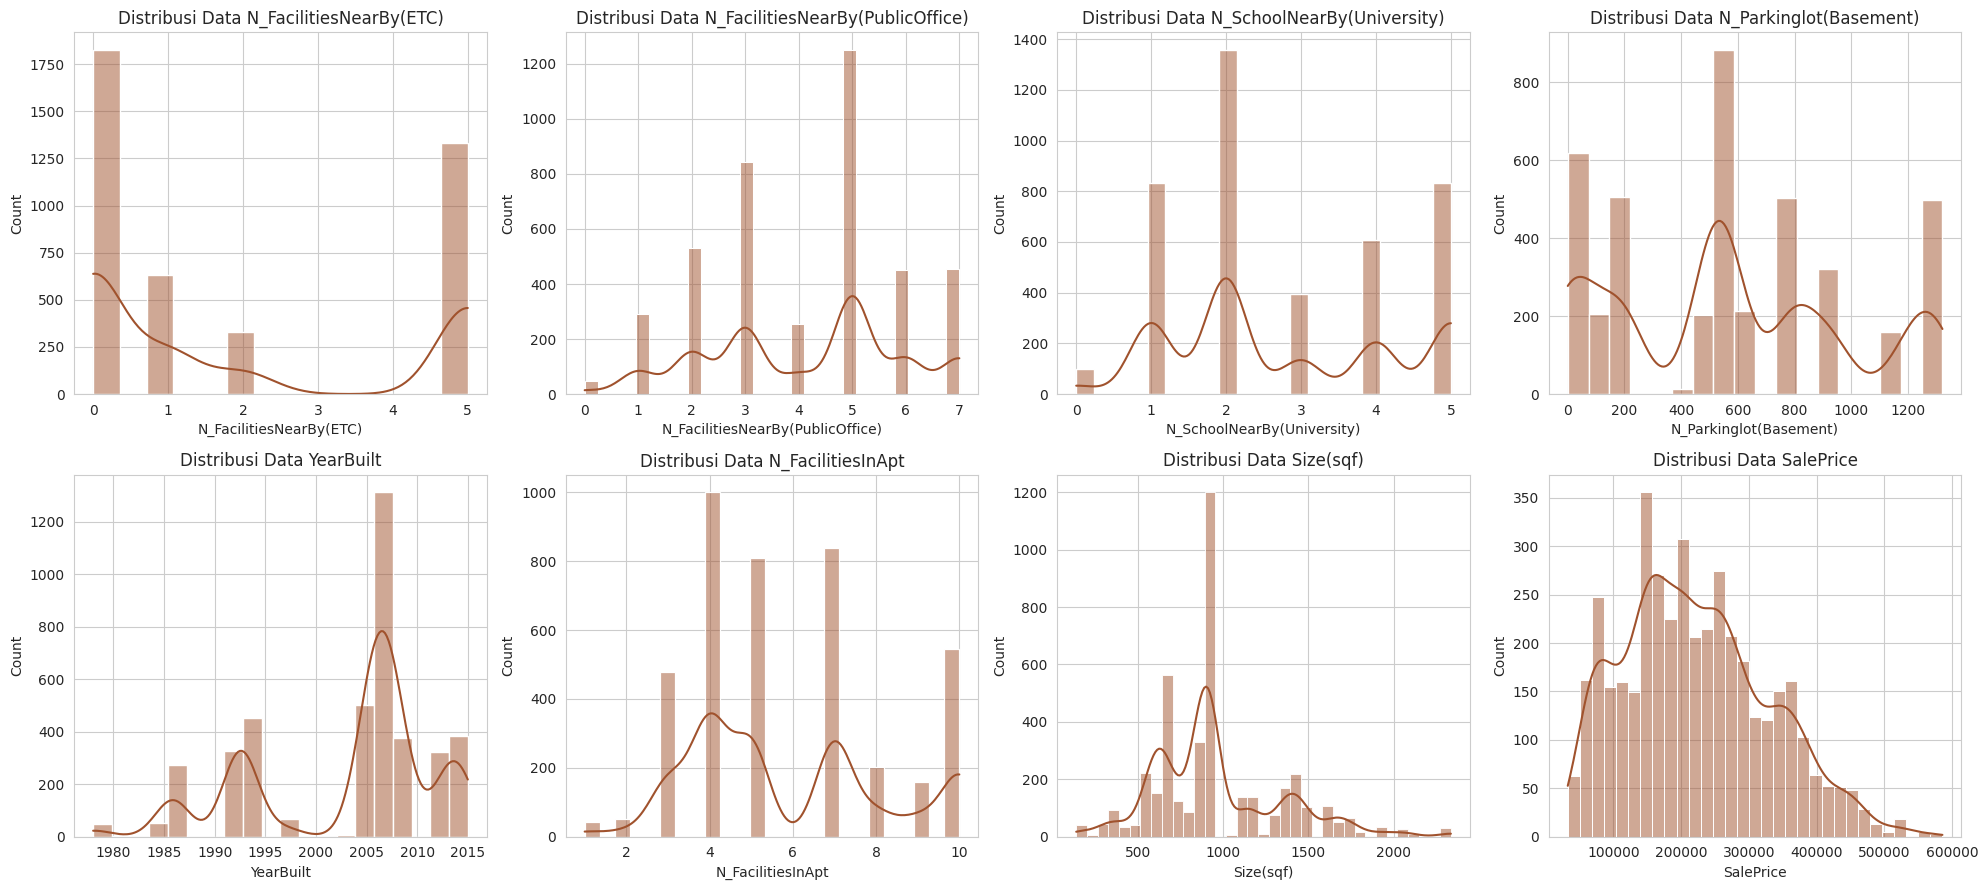

In [7]:
# Mengumpulkan kolom numerik dalam satu variable

all_numeric_cols = ["N_FacilitiesNearBy(ETC)", "N_FacilitiesNearBy(PublicOffice)",
                    "N_SchoolNearBy(University)", "N_Parkinglot(Basement)",
                    "YearBuilt", "N_FacilitiesInApt", "Size(sqf)", "SalePrice"]

# Melakukan proses plotting histogram untuk masing-masing kolom numerik
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.flat, all_numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="sienna")
    ax.set_title(f"Distribusi Data {col}")
plt.tight_layout()
plt.show()

In [8]:
# Menghitung skewness/kecondongan dari distribusi data masing-masing kolom
  # Negatif = Left-Skewed (Puncak Kurva berada di sebelah kanan - nilai mean lebih kecil daripada median/modus)
  # Positive = Right-Skewed (Puncak Kurva berada di sebelah kiri - nilai mean lebih besar daripada median/modus)

skew_table = df[all_numeric_cols].skew().sort_values(ascending=False).rename("skewness").to_frame()
skew_table

,skewness
Size(sqf),0.875841
N_FacilitiesNearBy(ETC),0.568429
N_FacilitiesInApt,0.452692
SalePrice,0.452321
N_SchoolNearBy(University),0.268935
N_Parkinglot(Basement),0.262595
N_FacilitiesNearBy(PublicOffice),-0.173557
YearBuilt,-0.807233


**Insight Distribusi Kolom Numerik**

| No. | Feature | Insight |
|---|---|---|
| 1 | `N_FacilitiesNearBy(ETC)` | Kebanyakan apartemen tidak memiliki fasilitas terdekat (`0`) yang berada paling kiri distribusi data tetapi distribusi terbanyak selanjutnya berada di paling kanan data - hampir tidak ada fasilitas terdekat berjumlah 3-4 |
| 2 | `N_FacilitiesNearBy(PublicOffice)` | Persebaran data hampir simetris berada tersebar di seluruh nilai feature dengan puncak berada di nilai 3 dan 5 - menunjukkan terdapat cukup merata kantor publik di area-area apartemen |
| 3 | `N_SchoolNearBy(University)` | Data terkonsentrasi di 1-2 universitas terdekat - persebaran data juga hampir simetris yang menunjukkan setiap area apartemen memiliki fasilitas universitas di sekitarnya |
| 4 | `N_Parkinglot(Basement)` | Data termasuk right-skewed - kelompok terbesar memiliki nilai `0` parkir basement dilanjutkan dengan beberapa cluster berada di nilai 500-600 |
| 5 | `YearBuilt` | Data termasuk Left-Skewed - Apartemen banyak dibangun pada tahun 2005 ke atas |
| 6 | `N_FacilitiesInApt` |Data fasilitas cukup tersebar dengan puncak berada di nilai 4, dilanjutkan cluster 5 dan 7 dimana menunjukkan bahwa apartemen memiliki fasilitas yang cukup banyak dan sedikit yang hampir tidak memiliki fasilitas |
| 7 | `Size(sqf)` | Data menunjukkan Right-Skewed dimana size apartemen berada pada rentang data 650-950 sqf dengan sedikit daa yang berada di area kanan (menunjukkan apartemen mewah) |
| 8 | `SalePrice` (target) | Data menunjukkan Right Skewed dimana penjualan apartemen berada banyak di rentang 150,000 - 300,000 Won dan beberapa apartemen dijual dengan harga yang lebih mahal (kemungkinan menunjukkan data outlier) |

### 3.2 Correlation Heatmap

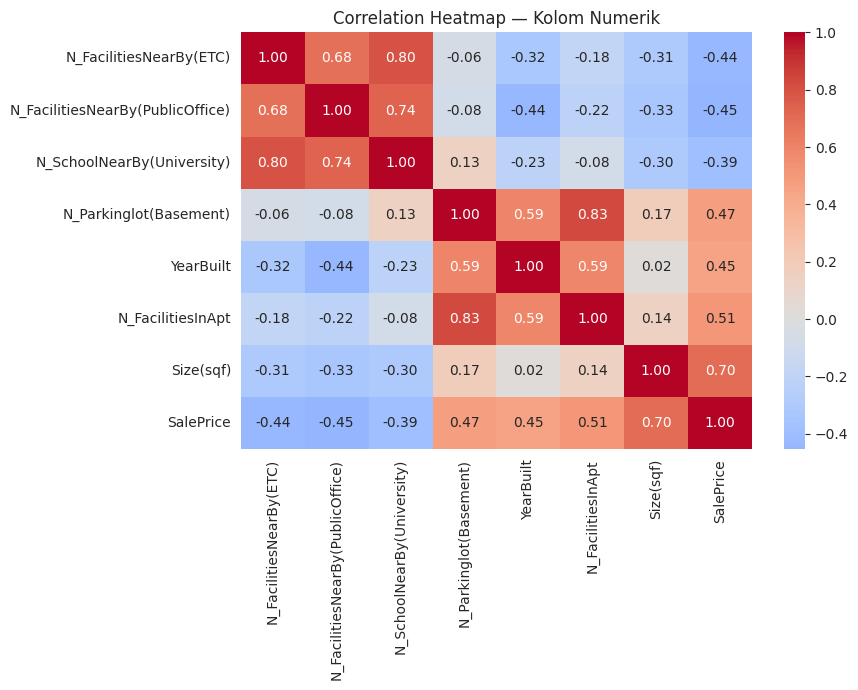

In [9]:
# Membuat Correlation Heatmap untuk kolom numerik

corr = df[all_numeric_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Kolom Numerik")
plt.tight_layout()
plt.show()

**Insight Correlation Heatmap**

| No. | Jenis Insight | Deskripsi |
|-----|--------------|-------------|
| 1 | **Kekuatan Korelasi Keseluruhan** | Seluruh feature memiliki rentang korelasi antara 0.3-0.7 terhadap harga apartemen - hal ini menunjukkan masing-masing feature memiliki korekasi yang cukup berarto terhadap harga jual apartemen |
| 2 | **Korelasi Positif Tertinggi** | **Size Apartemen** merupakan feature yang memiliki korelasi tertinggi (0.7), dapat diinterpretasikan semakin besar apartemen maka akan semakin tinggi harga jual apartemen|
| 3 | **Korelasi Positif Medium** | - Beberapa feature korelasi positif lainnya yang menunjukkan **korelasi positif medium**  <br> - **Jumlah Fasilitas Apartemen**  <br> - **Tahun Bangun**  <br> - **Jumlah lapangan parkir basement** <br> Hal ini dapat diinterpretasikan bahwa semakin banyak fasilitas dan tempat parkir maka akan tinggi harga jual apartemen |
| 4 | **Korelasi Negatif** | Beberapa feature dibawah ini memiliki korelasi negatif <br> - **Jumlah Kantor Publik terdekat**  <br> - **Jumlah Universitas terdekat**  <br> - **Jumlah Fasilitas terdekat lainnya** <br> Hal ini dapat diinterpretasikan bahwa apartemen dengan fasilitas atau institusi tertentu dapat menurunkan harga jual yang dapat disebabkan oleh kemungkinan bising/terlalu ramai |
| 5 | **Multicollinearity** | Multikolinearity dapat mungkin terjadi jika ada korelasi kuat antar feature yang diobservasi terdapat <br> - **Jumlah Lapangan Parkir Basement** & **Jumlah Fasilitas Apartemen** (**0.83**) <br>- **Jumlah Fasilitas Terdekat lainnya** & **Jumlah Universitas Terdekat** (**0.80**) <br> - **Jumlah Kantor Publik Terdekat** & **Jumlah Universitas Terdekat** (**0.74**) <br> Hal ini dapat mempengaruhi interpretasi dari model regresi dan menyebabkan sulit membedakan pengaruh unik dari masing-masing feature|


### 3.3 Relasi antara Sale Price dengan berbagai Feature

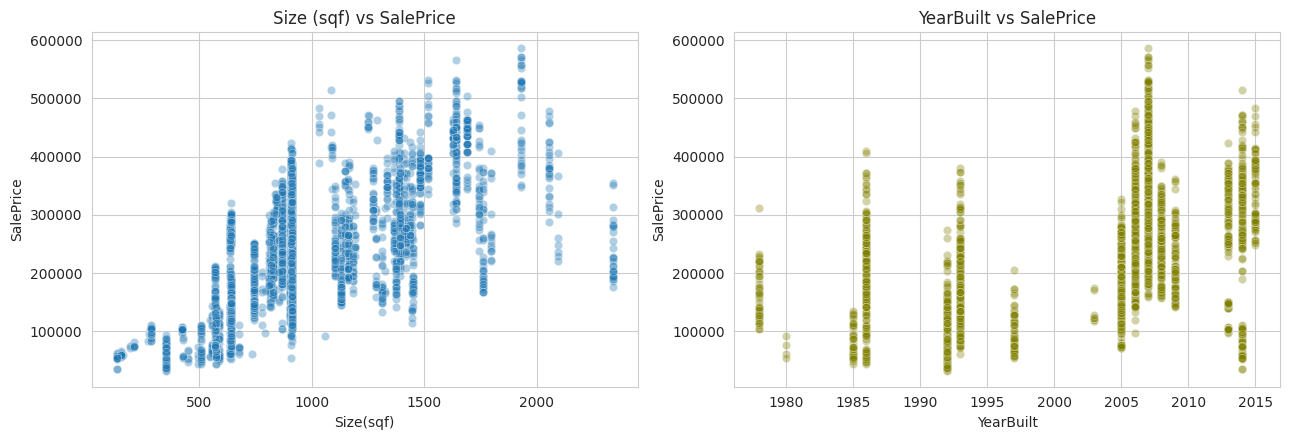

In [10]:
# Menampilkan persebaran data antar feature dengan Sale Price lewat ScatterPlot

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(data=df, x="Size(sqf)", y="SalePrice", alpha=0.35, ax=ax[0])
ax[0].set_title("Size (sqf) vs SalePrice")
sns.scatterplot(data=df, x="YearBuilt", y="SalePrice", alpha=0.35, ax=ax[1], color="olive")
ax[1].set_title("YearBuilt vs SalePrice")
plt.tight_layout()
plt.show()

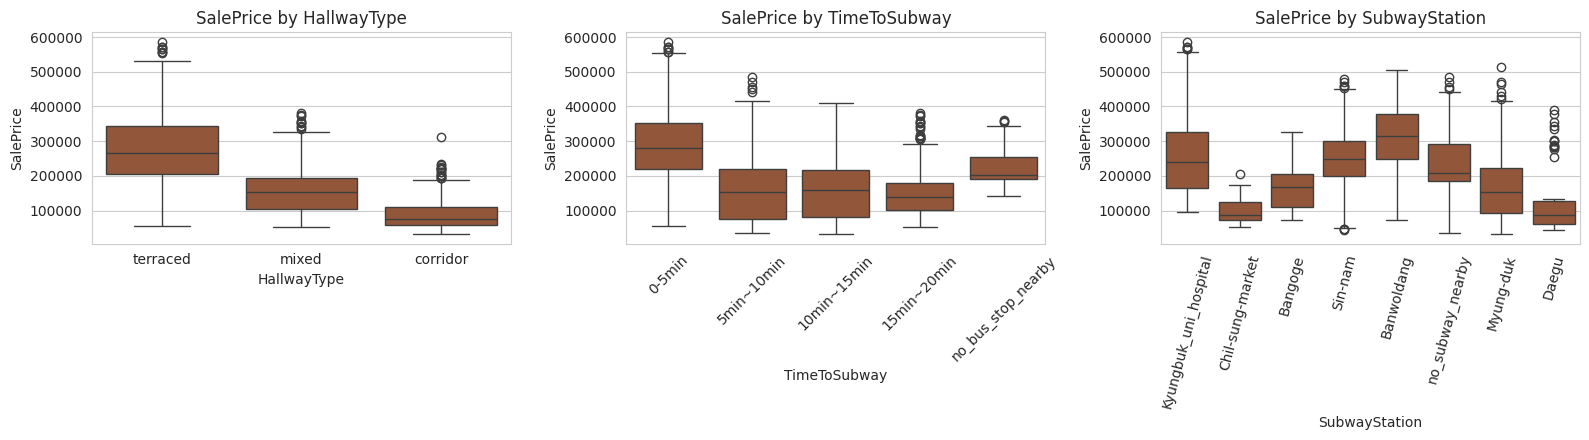

In [11]:
# Menampilkan persebaran data antar feature dengan Sale Price lewat Box Plot

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(data=df, x="HallwayType", y="SalePrice", ax=ax[0],color="sienna")
ax[0].set_title("SalePrice by HallwayType")
sns.boxplot(data=df, x="TimeToSubway", y="SalePrice", ax=ax[1],
            order=["0-5min","5min~10min","10min~15min","15min~20min","no_bus_stop_nearby"], color="sienna")
ax[1].set_title("SalePrice by TimeToSubway")
ax[1].tick_params(axis="x", rotation=45)
sns.boxplot(data=df, x="SubwayStation", y="SalePrice", ax=ax[2], color="sienna")
ax[2].set_title("SalePrice by SubwayStation")
ax[2].tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()

**Insights :**

Berdasarkan scatterplot dan boxplot di atas - Nilai `SalePrice` memiliki beberapa pola berdasarkan beberapa feature berikut:

* Luas rumah berbanding **positif** dengan harga jual—rumah yang lebih besar cenderung lebih mahal, tetapi variasinya tetap besar. Artinya, **luas bukan satu-satunya penentu harga**.
* Tahun pembangunan **tidak menunjukkan pola linear yang kuat**. Properti baru, terutama sekitar 2005–2008 dan 2013–2015, memiliki banyak harga tinggi, tetapi rumah lama pun dapat bernilai mahal.
* Rumah tipe `terraced` memiliki harga median tertinggi, disusul `mixed`, sementara `corridor` paling rendah. Tipe properti tampak menjadi pembeda harga yang jelas.
* Kedekatan dengan subway bernilai premium: rumah dengan waktu tempuh `0–5` menit memiliki **median harga tertinggi**. Harga cenderung menurun pada jarak `5–20` menit, meskipun kategori tanpa halte terdekat masih memiliki median relatif tinggi—kemungkinan dipengaruhi faktor lokasi atau karakter rumah lain.
* Lokasi stasiun juga berpengaruh: area `Banwoldang` memiliki median harga tertinggi, sedangkan `Chil-sung-market` dan `Daegu` cenderung lebih rendah.



## 4. Data Preprocessing
----

Pada bagian ini - kita akan melakukan beberapa proses terakhir sebelum data benar-benar bersih untuk digunakan dalam training model Machine Learning
1. Duplicate Cleaning
2. Deteksi Data Outlier

### 4.1 Duplicate Cleaning

In [12]:
# Duplicate Cleaning
data_before = df.shape[0] # Jumlah data sebelum dihapus duplikat
df = df.drop_duplicates().reset_index(drop=True)
data_after = df.shape[0] # Jumlah data setelah dihapus duplikat
print(f"Menghapus {data_before - data_after} data duplikat -> Setelah dihapus maka data final sebanyak: {data_after} baris")

Menghapus 1422 data duplikat -> Setelah dihapus maka data final sebanyak: 2701 baris


### 4.2 Deteksi Outlier (Kolom Numerik, Metode IQR)

Tahap ini dilakukan untuk memastikan apakah feature pada dataset memiliki nilai outlier dengan menggunakan metode IQR (menandai data diluar `Q1 - 1.5*IQR` atau `Q3 + 1.5*IQR`). Data akan direview terlebih dahulu sebelum diputuskan apakah data akan di-*drop* atau tidak secara statistik yang dapat menyebabkan kehilangan informasi penting.

Chart Boxplot untuk Feature Numerik: 


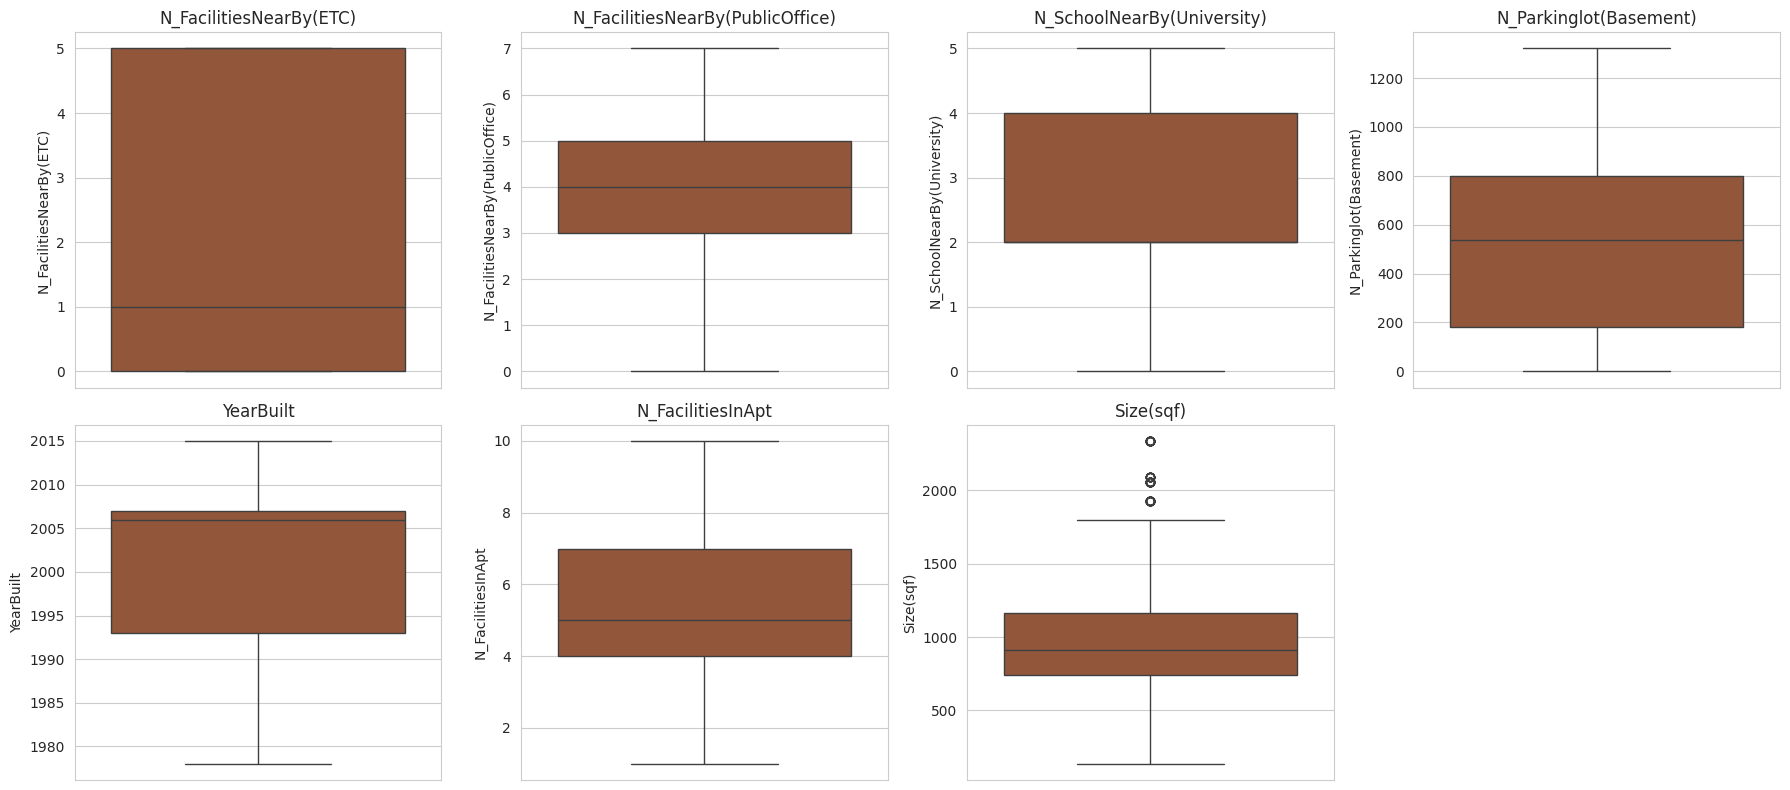


Menampilkan Table Data Outlier:


,feature,lower_bound,upper_bound,n_outliers,pct_outliers
6,Size(sqf),107.0,1803.0,84,0.0311
1,N_FacilitiesNearBy(PublicOffice),0.0,8.0,0,0.0000
0,N_FacilitiesNearBy(ETC),-7.5,12.5,0,0.0000
2,N_SchoolNearBy(University),-1.0,7.0,0,0.0000
3,N_Parkinglot(Basement),-744.5,1723.5,0,0.0000
4,YearBuilt,1972.0,2028.0,0,0.0000
5,N_FacilitiesInApt,-0.5,11.5,0,0.0000


In [13]:
# Menampilkan Chart BoxPlot untuk melakukan deteksi data outlier

numeric_check_cols = ["N_FacilitiesNearBy(ETC)", "N_FacilitiesNearBy(PublicOffice)",
                      "N_SchoolNearBy(University)", "N_Parkinglot(Basement)",
                      "YearBuilt", "N_FacilitiesInApt", "Size(sqf)"]

print("Chart Boxplot untuk Feature Numerik: ")
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, numeric_check_cols):
    sns.boxplot(y=df[col], ax=ax, color="sienna")
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()
print()

# Membuat DataFrame berisikan jumlah data outlier pada masing-masing feature

outlier_summary = []
outlier_masks = {}
for col in numeric_check_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_masks[col] = mask
    outlier_summary.append({
        "feature": col, "lower_bound": lower, "upper_bound": upper,
        "n_outliers": mask.sum(), "pct_outliers": mask.mean()
    })

outlier_summary_df = pd.DataFrame(outlier_summary).sort_values("n_outliers", ascending=False)
print("Menampilkan Table Data Outlier:")
outlier_summary_df

Berdasarkan deteksi outlier di atas, hanya `Size(sqf)` yang memiliki nilai outlier di dalam dataset sebanyak **84** data, yang tergolong kecil. Kita akan melihat lebih detail dan mengecek untuk 84 data ini seperti apa persebaran datanya.

In [14]:
# Melakukan pengecekan untuk data outlier
size_outliers = df[outlier_masks["Size(sqf)"]]

print(f"{len(size_outliers)} baris ({len(size_outliers)/len(df):.1%} jumlah data) merupakan outlier: \n")
display(size_outliers[["Size(sqf)", "SalePrice", "HallwayType", "YearBuilt", "N_Parkinglot(Basement)"]].describe())
print()

# Melakukan pengecekan berdasarkan Type Hallway (Sebelumnya kita tahu bahwa type terraced dan mixed merupakan apartemen yang memiliki nilai jual lebih tinggi)
print("HallwayType Breakdown:")
display(size_outliers["HallwayType"].value_counts())

84 baris (3.1% jumlah data) merupakan outlier: 



,Size(sqf),SalePrice,YearBuilt,N_Parkinglot(Basement)
count,84.000000,84.000000,84.000000,84.000000
mean,2095.523810,361288.654762,2000.726190,738.357143
std,164.622568,110930.197860,7.721588,417.719357
min,1928.000000,176991.000000,1986.000000,0.000000
25%,1928.000000,276548.500000,1993.000000,536.000000
50%,2056.000000,368442.000000,2006.000000,536.000000
75%,2337.000000,424778.000000,2007.000000,1270.000000
max,2337.000000,585840.000000,2007.000000,1270.000000



HallwayType Breakdown:


,count
HallwayType,
terraced,60
mixed,24


Berdasarkan analisis di atas:
* Data outlier merupakan data yang dimiliki oleh `terraced` dan `mixed` dimana berdasarkan analisis sebelumnya mengenai hubungan antara `HallwayType` dan `SalePrice` menunjukkan bahwa tipe apartemen ini termasuk dalam apartemen high-end atau mewah, sehingga belum tentu data error
* Jika dilihat dari feature numerik lainnya - hal ini sangat masuk akal dimana apartemen high-end atau mewah akan semakin memiliki ukuran yang besar maka akan semakin tinggi `SalePrice` dan fasilitas lapangan parkir.
* Menghilangkan 3% data ini dapat menyebabkan kita kehilangan data penting untuk data apartemen high-end atau mewah sehingga dapat mempengaruhi model dalam memberikan rekomendasi terhadap harga jual apartemen mewah

Oleh sebab itu, melalui analisis ini kita **Tidak Menghapus Data** dan akan tetap memasukkan dalam training Model Machine Learning kita.

## 5. Feature Engineering & Selection
----

Pada bagian ini - dengan mendapatkan informasi terkait konteks dan EDA yang sudah dilakukan, akan ada tambahan 2 step sebelum menuju tahap modeling:
1. Feature Engineering
2. Feature Selection

### 5.1 Feature Engineering

Kita akan menambahan dua feature tambahan yang berupa:
1. **`Age`** = `2015 - YearBuilt` - Berdasarkan dataset yang ada tahun 2015 merupakan data tahun terakhir untuk apartemen yang dibangun. Dengan mengetahui umur bangunan akan memberikan interpretasi yang lebih mudah untuk mengetahui apakah bangunan baru akan memiliki harga yang lebih tinggi atau tidak

2. **`NearbyFacilitiesScore`** = berdasarkan correlation heatmap, beberapa feature fasilitas terdekat memiliki korelasi yang cukup kuat antara 0.74-0.83 sehingga kita dapat menggabungkan feature tersebut menjadi satu daripada menjadi tiga feature yang berbeda. Kita akan menggabungkan melalui mean dari normalisasi z-score untuk ketiga feature (`N_FacilitiesNearBy(ETC)`, `N_FacilitiesNearBy(PublicOffice)`, `N_SchoolNearBy(University)`).

In [16]:
# Melakukan Feature Engineering untuk feature "Age"
df["Age"] = 2015 - df["YearBuilt"]

# Melakukan Feature Engineering untuk feature "NearbyFacilitiesScore"

nearby_cols = ["N_FacilitiesNearBy(ETC)", "N_FacilitiesNearBy(PublicOffice)", "N_SchoolNearBy(University)"]
nearby_z = (df[nearby_cols] - df[nearby_cols].mean()) / df[nearby_cols].std()
df["NearbyFacilitiesScore"] = nearby_z.mean(axis=1)

# Menampilkan sebagian data utama dengan tambahan dua feature baru
display(df[["YearBuilt", "Age", *nearby_cols, "NearbyFacilitiesScore"]].head())
print()

# Melakukan pengecekan korelasi terhadap tambahan dua feature baru
print("Korelasi dengan SalePrice:")
display(df[["Age", "NearbyFacilitiesScore", "SalePrice"]].corr()["SalePrice"])

,YearBuilt,Age,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),NearbyFacilitiesScore
0,2007,8,0.0,3.0,2.0,-0.624801
1,1986,29,1.0,5.0,1.0,-0.338349
2,1997,18,1.0,7.0,3.0,0.457979
3,2005,10,5.0,5.0,4.0,0.945580
4,2006,9,0.0,1.0,2.0,-0.978004



Korelasi dengan SalePrice:


,SalePrice
Age,-0.502638
NearbyFacilitiesScore,-0.409915
SalePrice,1.000000


Melalui Feature Engineering diatas dan melihat hasil korelasi dengan SalePrice:
1. `Age`: Feature ini memiliki korelasi sebesar -0.5 yang berarti memiliki hubungan negatif dengan SalePrice, hal ini cukup masuk akal dimana semakin tinggi usia sebuah bangunan maka akan menurunkan harga jual dari Apartemen
2. `NearbyFacilitiesScore`: Feature ini memiliki korelasi sebesar -0.4 dimana jika dibandingkan dengan 3 feature yang belum digabungkan memiliki korelasi rentang -0.39 hingga -0.44 yang menunjukkan bahwa feature gabungan ini masih memiliki arah dan kekuatan korelasi yang mirip dengan 3 feature tersebut

### 5.2 Feature Selection

Setelah melakukan Feature Engineering, maka kita akan melakukan pemilihan feature yang akan benar-benar digunakan dalam training untuk Model Machine Learning.

Kita akan menggunakan **Variance Inflation Factor (VIF)** untuk mengecek multicollinearity diantara feature numerik yang kita miliki. Standard VIF > 10 merupakan batas bahwa feature tersebut dapat diprediksi hampir sepenuhnya oleh feature yang lain, sehingga kita akan mencari feature dengan VIF yang rendah untuk mengurangi noise.

In [17]:
# Membuat fungsi menghitung VIF
def compute_vif(frame, cols):
    X_vif = frame[cols].assign(const=1)
    vif = pd.DataFrame()
    vif["feature"] = cols
    vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(cols))]
    return vif.sort_values("VIF", ascending=False)

# Menghitung VIF sebelum feature Engineering
original_numeric = ["N_FacilitiesNearBy(ETC)", "N_FacilitiesNearBy(PublicOffice)",
                     "N_SchoolNearBy(University)", "N_Parkinglot(Basement)",
                     "YearBuilt", "N_FacilitiesInApt", "Size(sqf)"]

print("VIF SEBELUM Feature Engineering:")
display(compute_vif(df, original_numeric))

VIF SEBELUM Feature Engineering:


,feature,VIF
3,N_Parkinglot(Basement),4.802396
5,N_FacilitiesInApt,3.922794
2,N_SchoolNearBy(University),3.894182
0,N_FacilitiesNearBy(ETC),3.377062
1,N_FacilitiesNearBy(PublicOffice),3.039617
4,YearBuilt,2.284940
6,Size(sqf),1.304118


In [18]:
# Menghitung VIF setelah feature Engineering
engineered_numeric = ["NearbyFacilitiesScore", "N_Parkinglot(Basement)",
                      "Age", "N_FacilitiesInApt", "Size(sqf)"]

print("VIF SETELAH feature engineering menggunakan NearbyFacilities Score dan Age:")
display(compute_vif(df, engineered_numeric))

VIF SETELAH feature engineering menggunakan NearbyFacilities Score dan Age:


,feature,VIF
1,N_Parkinglot(Basement),4.496240
3,N_FacilitiesInApt,3.754856
2,Age,2.055111
0,NearbyFacilitiesScore,1.545055
4,Size(sqf),1.298326


**Keputusan:** Berdasarkan perhitungan VIF sebenernya tidak ada feature yang melewati threshold >10 sehingga dapat dikatakan baik menggunakan feature yang lama ataupun feature yang setelah dilakukan feature engineering memiliki nilai yang masih dalam batas wajar.

Namun, jika diperhatikan lebih lanjut `NearbyFacilitiesScore` dapat menggantikan tiga feature yang telah di normalisasi dan memiliki VIF yang lebih rendah. Sebelum dilakukan feature engineering VIF untuk ketiga feature tersebut memiliki rentang 3.0 - 3.9 dibandingkan dengan feature kombinasi memiliki VIF 1.5. Selain itu, Feature `Age` memiliki VIF tidak jauh berbeda dengan `YearBuilt`, namun memiliki interpretasi yang lebih baik sehingga kita akan menggunakan feature ini.

Hal lain yang perlu diperhatikan adalah feature `N_Parkinglot(Basement)` dan `N_FacilitiesInApt` memiliki VIF yang cukup tinggi antara 3.7 - 4.5 setelah mengkombinasikan ketiga feature - namun masih dibawah batas 10 sehingga masih dapat kita gunakan lebih lanjut dan memiliki korelasi positf yang lumayan tinggi ~0.5 daripada menggabungkan menjadi satu kombinasi

**Final Feature:** `Age`, `NearbyAmenitiesScore`, `N_Parkinglot(Basement)`, `N_FacilitiesInApt`, `Size(sqf)` (numerik) + `HallwayType`, `TimeToSubway`, `SubwayStation` (kategori).

## 6. Modeling
----

Pada bagian ini kita akan mulai membangun model machine learning - terdapat beberapa bagian dalam proses Modeling ini:
1. Train-Test Split
2. Encoding Process
3. Regression Modeling

### 6.1 Train-Test Split

Sebelum melakukan proses encoding or scaling kita perlu memisahkan dataset menjadi data training dan data validasi/test untuk menghindari data leakage.
Proses encoding/scaling hanya akan dilakukan pada dataset training saja.

In [19]:
# Final Feature yang digunakan dalam model machine learning
final_features = ["Age", "NearbyFacilitiesScore", "N_Parkinglot(Basement)", "N_FacilitiesInApt", "Size(sqf)",
                "HallwayType", "TimeToSubway", "SubwayStation"]

# Melakukan assignment feature (X) & target (y)
X = df[final_features]
y = df["SalePrice"]

# Melakukan Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Dataset Training: {X_train.shape[0]} data")
print(f"Test shape: {X_test.shape[0]} data")

Dataset Training: 2160 data
Test shape: 541 data


### 6.2 Encoding Process

- **Feature Numerik** → `StandardScaler` - kita akan melakukan scaling untuk memudahkan model kita mempelajari data numerik dengan skala yang lebih terstandarisasi (tidak ada skala yang terlalu tinggi atau terlalu rendah) dimana mean = 0 & std = 1
- **Feature Kategori** → `OneHotEncoder` - Feature kategori perlu diubah menjadi angka agar model bisa mempelajari karena model tidak dapat membaca teks/label secara langsung - ketiga feature yang kita miliki merupakan data nominal sehingga perlu dilakukan OneHotEncoder untuk membuat kolom biner secara terpisah tanpa memunculkan urutan yang tidak nyata
  - `TimeToSubway` termasuk dalam kategori Nominal meskipun terdapat range waktu antar satu kelas dengan kelas lainnya yang dapat diurutkan namun dia memiliki nilai `no_bus_stop_nearby` yang tidak memiliki urutan
- Scaling & Encoding akan dibungkus didalam `ColumnTransformer` agar dapat digunakan untuk dataset kita saat melakukan modeling

In [22]:
# Memisahkan feature numerik dan kategori sebagai input untuk scaling/encoding
feature_numerik = ["Age", "NearbyFacilitiesScore", "N_Parkinglot(Basement)", "N_FacilitiesInApt", "Size(sqf)"]
feature_kategori = ["HallwayType", "TimeToSubway", "SubwayStation"]

# Scaling & Encoding akan dibungkus dalam ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), feature_numerik),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), feature_kategori),
    ]
)

print("✅ Preprocessor untuk Scaling & Encoding siap dijalankan")

✅ Preprocessor untuk Scaling & Encoding siap dijalankan


### 6.3 Regression Modeling

Kita membandingkan lima model regresi, masing-masing dibungkus dengan `preprocessor` yang sama di dalam sebuah `Pipeline`. **Cara kerja masing-masing model:**

- **Linear Regression** — Menarik satu garis lurus terbaik untuk memprediksi harga dari fitur-fitur yang ada. Sederhana dan cepat, tapi kurang akurat kalau hubungan datanya tidak benar-benar linear.
- **Ridge Regression** — Sama seperti Linear Regression, tapi dengan penyesuaian tambahan supaya model tidak terlalu bergantung pada satu-dua fitur saja. Membuat hasil lebih stabil.
- **Random Forest Regressor** — Menggabungkan banyak decision tree dan merata-ratakan hasilnya. Lebih akurat dan tidak mudah overfitting dibanding satu tree saja.
- **Gradient Boosting Regressor** — Membangun tree satu per satu secara bertahap, di mana tiap tree baru memperbaiki kesalahan tree sebelumnya. Biasanya lebih akurat dari Random Forest, tapi perlu diatur lebih hati-hati.
- **XGBoost Regressor** — Versi lebih cepat dan efisien dari Gradient Boosting, dengan hasil yang biasanya sedikit lebih baik.

Setiap model dievaluasi dengan **5-fold cross-validation pada training set** dimana data training akan dibagi menjadi 5 bagian sama rata,  kemudian 4 bagian akan digunakan sebagai training dan 1 bagian akan digunakan sebagai validasi agar menghindari overfitting atau underfitting (sehingga data test tetap tidak tersentuh sampai tahap akhir).

Lalu, mengevaluasi model berdasarkan 5 metrik evaluasi:

| Metrik | Alasan Penggunaan |
|---|---|
| **RMSE (mean)** | Rata-rata besar kesalahan prediksi, dengan penalti lebih besar untuk kesalahan yang sangat meleset. |
| **RMSE (stdev)** | Menunjukkan seberapa konsisten performa model di berbagai subset data (semakin kecil, semakin stabil). |
| **MAE** | Rata-rata besar kesalahan prediksi dalam satuan Won, tanpa memberi penalti ekstra untuk kesalahan besar. |
| **MAPE** | Rata-rata besar kesalahan dalam bentuk persentase, memudahkan perbandingan antar harga rendah dan tinggi. |
| **R²** | Seberapa besar variasi harga yang berhasil dijelaskan oleh model, dalam skala 0 sampai 1. |

Pemilihan model terbaik akan berdasarkan nilai **RMSE (mean)** terendah dibandingkan model lain - dengan memperhatikan metrik-metrik lain sebagai *sanity check*. RMSE dipakai karena satuannya sama dengan harga asli (jadi gampang diartikan), dan memberi penalti lebih besar untuk kesalahan prediksi yang sangat meleset — cocok karena kesalahan besar pada unit mahal lebih merugikan bisnis dibanding kesalahan kecil yang tersebar merata

In [23]:
# Mempersiapkan 5 Model Regresi yang akan dievaluasi tanpa tuning parameter apapun
# n_jobs=-1: pakai semua core CPU yang tersedia biar prosesnya lebih cepat

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
}

# Fungsi scorer khusus untuk menghitung RMSE (Root Mean Squared Error)
# sklearn secara default menganggap "skor lebih tinggi = lebih baik", padahal RMSE justru sebaliknya (makin kecil makin baik)
# makanya hasilnya dikasih tanda negatif (-), supaya tetap konsisten dengan konvensi scorer sklearn

def rmse_scorer(estimator, X, y):
    preds = estimator.predict(X)
    return -np.sqrt(mean_squared_error(y, preds))

# Menyiapkan skema 5-fold cross-validation
# shuffle=True: data diacak dulu sebelum dibagi fold, supaya urutan asli data tidak mempengaruhi hasil

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = [] # list kosong untuk menampung hasil evaluasi tiap model

# Looping untuk melatih & mengevaluasi setiap model satu per satu

for name, model in models.items():
    # Menggabungkan preprocessing (scaler + encoder) dengan model jadi satu pipeline utuh
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])

    # Menjalankan cross-validation dengan 4 metrik evaluasi sekaligus:
    # - rmse: fungsi custom kita di atas
    # - r2: koefisien determinasi (seberapa besar variasi harga yang berhasil dijelaskan model)
    # - mae: rata-rata besar kesalahan absolut (dalam satuan asli harga)
    # - mape: rata-rata besar kesalahan dalam bentuk persentase (mudah diinterpretasikan secara relatif)
    # Catatan: mae & mape juga bertanda negatif dari sklearn (neg_...), sama seperti alasan rmse di atas

    scores = cross_validate(
        pipe, X_train, y_train, cv=kf,
        scoring={"rmse": rmse_scorer, "r2": "r2", "mae": "neg_mean_absolute_error", "mape":"neg_mean_absolute_percentage_error"},
        n_jobs=-1
    )

    # Menyimpan rata-rata (dan std untuk RMSE) dari 5 fold ke dalam list

    cv_results.append({
        "Model": name,
        "CV RMSE (mean)": -scores["test_rmse"].mean(),
        "CV RMSE (std)": scores["test_rmse"].std(),
        "CV R2 (mean)": scores["test_r2"].mean(),
        "CV MAE (mean)": -scores["test_mae"].mean(),
        "CV MAPE (mean)": -scores["test_mape"].mean()
    })

# Mengubah hasil ke DataFrame dan mengurutkan dari RMSE terkecil (model terbaik) ke terbesar
cv_df = pd.DataFrame(cv_results).sort_values("CV RMSE (mean)")
cv_df

,Model,CV RMSE (mean),CV RMSE (std),CV R2 (mean),CV MAE (mean),CV MAPE (mean)
3,Gradient Boosting,45888.350456,1057.408337,0.809965,37121.209676,0.191752
4,XGBoost,46239.027754,1246.442108,0.807051,37330.873437,0.192209
2,Random Forest,46257.475607,1345.770292,0.806922,37314.784691,0.192643
1,Ridge,52106.686845,1245.967465,0.755121,42064.193684,0.218840
0,Linear Regression,52111.686275,1247.533661,0.755074,42040.707681,0.218891


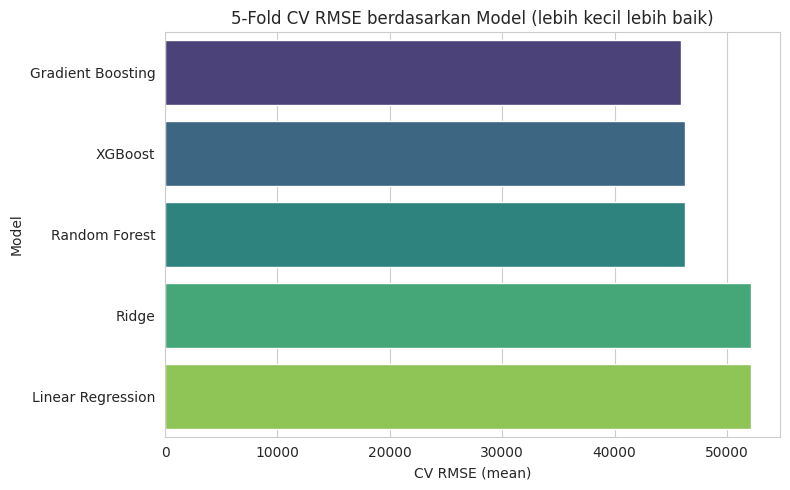

In [24]:
# Menampilkan perbandingan CV RMSE dalam chart

plt.figure(figsize=(8, 5))
sns.barplot(data=cv_df, x="CV RMSE (mean)", y="Model", hue="Model", legend=False, palette="viridis")
plt.title("5-Fold CV RMSE berdasarkan Model (lebih kecil lebih baik)")
plt.tight_layout()
plt.show()

**Model Evaluation**:

Berdasarkan perbandingan nilai RMSE di atas - kita dapat menyimpulkan bahwa model **Gradient Boosting** memiliki **RMSE yang paling rendah** dibandingkan model lainnya. Selain itu berdasarkan metrik lainnya
1. RMSE (std): merupakan nilai paling terendah yang memberikan bahwa model memberikan konsistensi yang lebih baik - tidak terlalu jauh variannya
2. R-squared: Mirip dengan R-squared model XGBoost dan Random Forest, namun relatif paling tinggi diantara semua model - memberikan interpretasi bahwa feature dapat menjelaskan variasi target `SalePrice` sebesar 81%
3. MAE & MAPE: Metrik lainnya yang memberikan nilai paling rendah dimana MAE mirip seperti RMSE namun menghitung absolut error dalam won dibanding RMSE yang akan menghukum kesalahan besar lebih berat. MAPE mirip MAE namun diinterpretasikan dalam bentuk persentase

Oleh sebab itu kita akan menggunakan Model Gradient Boosting untuk mengevaluasi pada data test kita.

## 7. Model Evaluation
----

Pada bagian ini setelah membangun model machine learning - Kita akan melakukan uji terakhir terhadap dataset kita

### Final Model Evaluation — Evaluasi terhadap Dataset Test

Setelah melakukan proses pemilihan model terbaik dari hasil cross-validation - kita akan melakukan latih ulang (refit) pada seluruh training set dan mengevaluasi satu kali pada test set yang belum pernah disentuh oleh Model.Kita juga akan mengevaluasi lebih dalam berdasarkan metrik-metrik di atas dengan mengkaitkan masalah bisnis untuk memberikan kemudahan menginterpretasikan model:

- **MAE** (Mean Absolute Error) — rata-rata kesalahan absolut dalam Won per listing; secara langsung memberi tahu pemilik properti "rata-rata, harga yang disarankan meleset sebanyak sekian Won." Paling mudah dijelaskan ke stakeholder non-teknis
- **RMSE** (Root Mean Squared Error) — mirip MAE, tapi mengkuadratkan error sebelum dirata-ratakan, sehingga memberi penalti jauh lebih besar untuk kesalahan besar. Ini penting di sini karena unit *mahal* yang salah harga secara signifikan lebih merugikan bisnis dibanding sedikit meleset pada banyak unit murah — RMSE menampilkan risiko ini, sedangkan MAE saja akan menyembunyikannya
- **MAPE** (Mean Absolute Percentage Error) — error yang dinyatakan sebagai *persentase* dari harga. Ini metrik paling ramah untuk stakeholder di rentang harga yang luas (kesalahan 30.000 Won punya arti yang sangat berbeda pada unit seharga 50.000 Won dibanding unit seharga 500.000 Won), kita jadikan acuan untuk goal evaluasi dataset test kita (MAPE ≤ 20%).
- **R²** — proporsi variasi harga yang berhasil dijelaskan oleh model; sebagai pengecekan cepat satu angka untuk kecocokan model secara keseluruhan, tapi sendirian tidak memberi tahu pemilik properti apa pun tentang besar kesalahan dalam satuan Won, makanya kita tidak bergantung pada metrik ini saja
- **Metrik bisnis custom — "% prediksi yang berada dalam ±10% dari harga sebenarnya"**: R²/RMSE/MAE sifatnya abstrak bagi stakeholder non-teknis. Metrik custom ini menjawab pertanyaan konkret: *"Kalau kita tampilkan harga yang disarankan ini, seberapa sering harganya memenuhi untuk benar-benar berguna?"*

In [31]:
# Pemilihan Model Terbaik
best_model_name = cv_df.iloc[0]["Model"]
print("Model terbaik:", best_model_name)

# Membangun pipeline final menggunakan model terbaik tadi
# preprocessor tetap dipakai supaya alur preprocessing konsisten dengan tahap CV sebelumnya
final_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", models[best_model_name]),
])

# Melatih ulang pipeline final menggunakan SELURUH training set supaya model belajar dari semua data training yang tersedia
final_pipe.fit(X_train, y_train)

# Melakukan proses prediksi dengan data test (belum pernah dilihat model)
y_pred = final_pipe.predict(X_test)

# Menghitung metrik evaluasi akhir di atas test set
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Menghitung metrik bisnis custom: seberapa besar persentase kesalahan tiap prediksi (dalam nilai absolut)
pct_error = np.abs(y_test - y_pred) / y_test
within_10pct = (pct_error <= 0.10).mean()

print(f"Nilai RMSE                            : {rmse:,.0f} Won")
print(f"Nilai MAE                             : {mae:,.0f} Won")
print(f"Nilai MAPE                            : {mape:.2%}")
print(f"Nilai R2                              : {r2:.1%}")
print(f"Prediksi +/-10% dari harga sebenarnya : {within_10pct:.1%} jumlah apartemen")
print()
print(f"Goal check (MAPE <= 20%): {'SUKSES ✅' if mape <= 0.20 else 'GAGAL ❌'}")

Model terbaik: Gradient Boosting
Nilai RMSE                            : 47,752 Won
Nilai MAE                             : 38,876 Won
Nilai MAPE                            : 19.82%
Nilai R2                              : 78.5%
Prediksi +/-10% dari harga sebenarnya : 31.8% jumlah apartemen

Goal check (MAPE <= 20%): SUKSES ✅


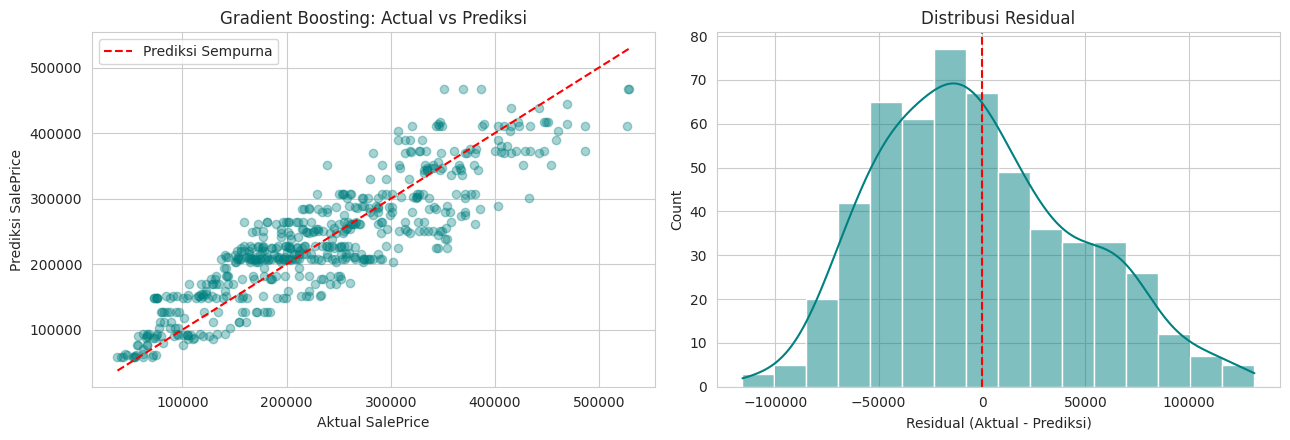

In [32]:
# Membuat kanvas untuk menampilkan grafik
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Grafik 1: Scatter plot antara harga asli vs harga hasil prediksi
ax[0].scatter(y_test, y_pred, alpha=0.35, color="teal")

# Membuat garis putus-putus merah sebagai acuan "prediksi sempurna"
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax[0].plot(lims, lims, "r--", label="Prediksi Sempurna")
ax[0].set_xlabel("Aktual SalePrice")
ax[0].set_ylabel("Prediksi SalePrice")
ax[0].set_title(f"{best_model_name}: Actual vs Prediksi")
ax[0].legend()

# Menghitung residual = selisih antara harga asli dan harga prediksi
# (residual positif = model under-predict, residual negatif = model over-predict)
residuals = y_test - y_pred

# Grafik 2: Histogram sebaran residual, untuk melihat apakah kesalahan model
sns.histplot(residuals, kde=True, ax=ax[1], color="teal")
ax[1].axvline(0, color="red", linestyle="--")
ax[1].set_title("Distribusi Residual")
ax[1].set_xlabel("Residual (Aktual - Prediksi)")

plt.tight_layout()
plt.show()

### Highlight: Evaluasi Model Final

- Model terbaik (`Gradient Boosting`) dipilih berdasarkan RMSE terendah dari hasil cross-validation, lalu dilatih ulang pada seluruh training set dan diuji sekali di test set yang belum pernah dilihat model sebelumnya. Interpretasi yang kita lakukan pada dataset test:
  - Goal utama melihat apakah MAPE dibawah 20% sebagai tolak ukur model memberikan rekomendasi harga dengan maksimal margin error ±20% - Model berhasil dan sukses menghasilkan MAPE dibawah 20%
- Grafik **Actual vs Predicted** menunjukkan seberapa dekat titik-titik prediksi dengan garis "prediksi sempurna" — semakin rapat ke garis, semakin akurat modelnya. Interpretasi dari Grafik diatas:
  - Sebagian besar titik mengumpul rapat di sekitar garis "Perfect prediction", terutama di rentang harga rendah–menengah (di bawah 300.000), menandakan model cukup akurat untuk mayoritas listing
  - Sebaran titik makin melebar di rentang harga tinggi (>300.000) — model cenderung kurang presisi untuk properti mahal, dengan beberapa titik terlihat cukup jauh dari garis ideal
- Grafik **Residual Distribution** menunjukkan sebaran kesalahan model; idealnya residual terpusat di sekitar 0 dan berbentuk simetris (tidak condong ke satu arah), menandakan model tidak punya bias sistematis dalam memprediksi harga. Interpretasi dari Grafik diatas:
  - Puncak distribusi berada sedikit di sebelah kiri angka 0 (sekitar -20.000), artinya untuk mayoritas listing, model sedikit **over-predict** (harga prediksi sedikit lebih tinggi dari harga asli)
  - Namun distribusi memiliki **ekor panjang ke arah kanan** (positif, sampai +130.000), menandakan ada sejumlah listing dengan **under-prediction** yang cukup besar — kemungkinan besar terjadi pada unit-unit bernilai tinggi, konsisten dengan sebaran yang melebar di grafik kiri untuk harga di atas 300.000
  - Distribusi tidak sepenuhnya simetris (sedikit skewed ke kanan), yang mengindikasikan model punya bias sistematis kecil dalam memprediksi unit-unit mahal — ini area yang bisa jadi fokus perbaikan lebih lanjut (misal lewat feature engineering tambahan atau tuning khusus untuk segmen harga tinggi)


## 8. Conclusion & Recommendation
----

### 8.1 Perbandingan Metrics: Cross-Validation (Training) vs Test Evaluation — Gradient Boosting

| Metric | CV (Training, mean) | Test Evaluation | Selisih |
|---|---|---|---|
| RMSE | 45,888.35 Won | 47,752 Won | +1,863.65 Won |
| MAE | 37,121.21 Won | 38,876 Won | +1,754.79 Won |
| MAPE | 19.18% | 19.82% | +0.64% |
| R² | 0.8100 | 0.7853 | -0.0247 |

**Highlight:** Performa model pada data test sedikit lebih rendah dibanding hasil cross-validation, namun selisihnya kecil (RMSE naik ~4%, R² turun ~2.5%), menunjukkan model tidak overfitting secara signifikan. MAPE test (19.82%) masih memenuhi target goal ≤20%.


### 8.2 Conclusion & Recommendation

**Apakah kita mencapai goal awal?** Target yang ditetapkan di Bagian 1 adalah MAPE ≤ 20% pada data yang belum pernah dilihat model (test data). Model final yang terpilih `Gradient Boosting` mencapai nilai MAPE yang diharapkan

**Dampak bisnis (terukur):** dengan MAPE sekitar 20% dan kira-kira 3 dari 10 listing di test set berada dalam rentang ±10% dari harga asli, model ini cukup akurat untuk dijadikan **harga saran awal**, bukan harga final karena masih terdapat margin error sekitar 20%. Hal ini memberikan panduan harga awal bagi pemilik/agen apartemen untuk menentukan harga dan melakukan informasi/research tambahan untuk mendapatkan harga final

**Keterbatasan model ini:**
- **Data:** hanya mencakup satu kota (Daegu), dengan rentang waktu hingga tahun 2015 saja; tidak ada data tambahan mengenai listing tersebut apakah memang terjual dengan harga tersebut atau hanya harga yang dipasarkan; sekitar 1.400 baris duplikat yang kita hapus tidak bisa ditelusuri ke bangunan spesifik mana dimana ada kemungkinan beberapa unit apartemen serupa memang dimiliki orang yang sama atau ditawarkan dengan harga yang sama untuk memastikan harga tetap kompetitif
- **Model:** model terbaik dipilih hanya berdasarkan rata-rata CV RMSE tanpa ada hyperparameter tuning, sehingga hasil ini merepresentasikan performa standard belum maksimal dari model

**Rekomendasi:**
1. Melakukan hyperparameter tuning pada model pemenang (`GridSearchCV`/`RandomizedSearchCV`) untuk mengecilkan gap MAPE
2. Melacak hasil transaksi yang sebenarnya (harga jual vs. harga listing, lama hari listing terpasang/days-on-market) untuk pada akhirnya memvalidasi model terhadap perilaku jual-beli yang nyata, bukan cuma harga listing
3. Menambahkan feature-feature lain yang seperti jumlah kamar tidur, jumlah kamar mandi, dll. yang dapat membantu menangkap lebih banyak faktor dalam penentuan harga apartemen
4. Mengulang investigasi baris duplikat dengan menggunakan identifier bangunan/unit jika tersedia, untuk memastikan keputusan pembersihan data di Bagian 4 tidak menyembunyikan satu development yang oversampled

## Appendix: Save Model in Pickle

In [33]:
import pickle

# Save Model
with open("gb_model_baseline.pkl", "wb") as f:
    pickle.dump(final_pipe, f)

In [34]:
# Load Model

with open("gb_model_baseline.pkl", "rb") as f:
    loaded_model = pickle.load(f)

new_predictions = loaded_model.predict(X_test)